In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
import warnings

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
try:
    df = pd.read_csv('/kaggle/input/datasets/karkavelrajaj/amazon-sales-dataset/amazon.csv')
    print(f"✅ Dataset loaded successfully. Shape: {df.shape}")
except FileNotFoundError:
    print("❌ Error: File not found. Please check the directory path.")

✅ Dataset loaded successfully. Shape: (1465, 16)


In [4]:
def clean_amazon_data(df):
    df_clean = df.copy()

    # 1. Clean Price Columns (Remove '₹', ',', and handle text)
    price_cols = ['discounted_price', 'actual_price']
    for col in price_cols:
        # Remove currency symbols and commas
        df_clean[col] = df_clean[col].astype(str).str.replace('₹', '', regex=False)
        df_clean[col] = df_clean[col].str.replace(',', '', regex=False)
        # Convert to numeric, coercing errors to NaN
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        # 2. Clean Rating Column (Handle the hidden '|' character)
    # Some rows contain garbage like '|'. We force coercion to NaN.
    df_clean['rating'] = pd.to_numeric(df_clean['rating'], errors='coerce')
    
    # Impute missing ratings with the Median to preserve distribution
    median_rating = df_clean['rating'].median()
    df_clean['rating'].fillna(median_rating, inplace=True)

    # 3. Clean Rating Count (Remove ',')
    df_clean['rating_count'] = df_clean['rating_count'].astype(str).str.replace(',', '', regex=False)
    df_clean['rating_count'] = pd.to_numeric(df_clean['rating_count'], errors='coerce')
    df_clean['rating_count'].fillna(0, inplace=True) # Assume 0 reviews if missing
     # 4. Feature Engineering: Accurate Discount Calculation
    # We recalculate this to ensure mathematical consistency
    df_clean['discount_pct_calc'] = ((df_clean['actual_price'] - df_clean['discounted_price']) / df_clean['actual_price']) * 100
    df_clean['discount_pct_calc'] = df_clean['discount_pct_calc'].round(2)

    # 5. Drop Irrecoverable Rows (Where price is missing)
    df_clean.dropna(subset=['discounted_price', 'actual_price'], inplace=True)

    return df_clean

# Execute Cleaning
df_final = clean_amazon_data(df)
print("✅ Data Cleaning Complete.")
print(df_final[['discounted_price', 'rating', 'rating_count']].dtypes)

✅ Data Cleaning Complete.
discounted_price    float64
rating              float64
rating_count        float64
dtype: object


In [5]:
v = df_final['rating_count']  # Vote count
R = df_final['rating']        # Average rating
C = df_final['rating'].mean() # Mean rating across the whole report
m = df_final['rating_count'].quantile(0.90) # Minimum votes required to be listed (90th percentile)

# 2. Calculate the Weighted Score
df_final['rating_bayesian'] = ((v / (v + m)) * R) + ((m / (v + m)) * C)

print(f"✅ Bayesian Rating Calculated.")
print(f"   > Global Mean Rating (C): {C:.2f}")
print(f"   > Minimum Votes Required (m): {m}")

# 3. Extract Categories for Analysis
df_final['main_category'] = df_final['category'].astype(str).str.split('|').str[0]
df_final['sub_category'] = df_final['category'].astype(str).str.split('|').str[-1]

✅ Bayesian Rating Calculated.
   > Global Mean Rating (C): 4.10
   > Minimum Votes Required (m): 39386.00000000012


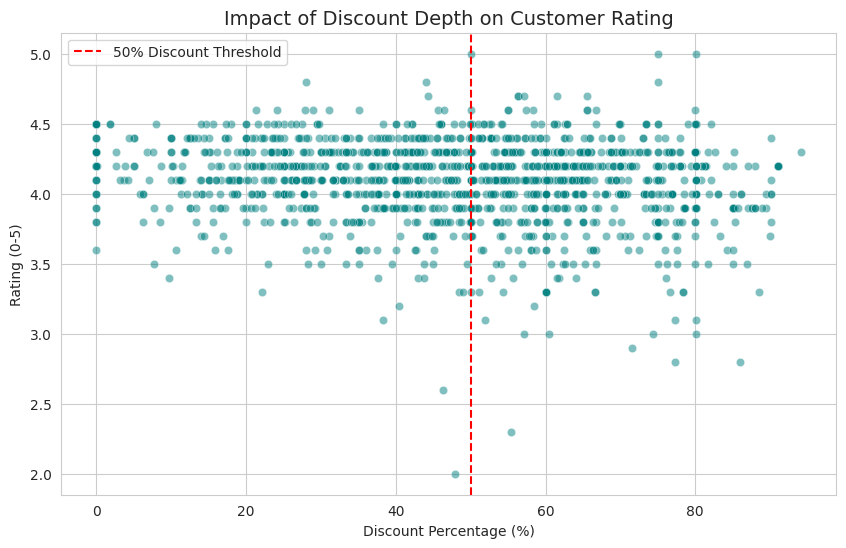

In [6]:
# 1. Visualization: Discount vs. Rating
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='discount_pct_calc', y='rating', alpha=0.5, color='teal')
plt.title('Impact of Discount Depth on Customer Rating', fontsize=14)
plt.xlabel('Discount Percentage (%)')
plt.ylabel('Rating (0-5)')
plt.axvline(x=50, color='red', linestyle='--', label='50% Discount Threshold')
plt.legend()
plt.show()

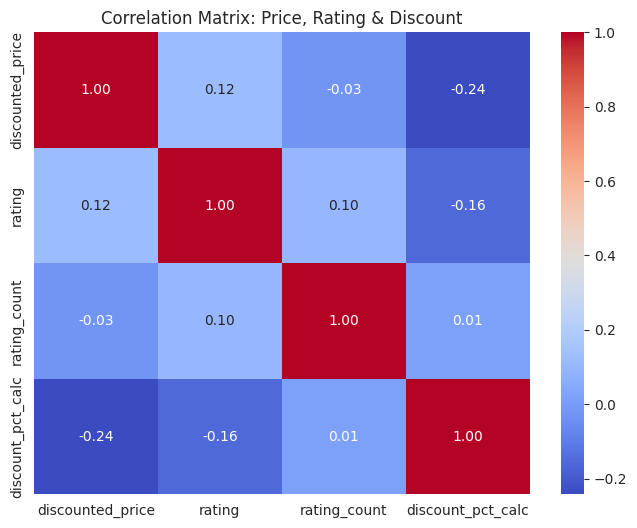

💡 Insight: There is a weak negative correlation between Discount % and Rating.
   This suggests that aggressive price cuts do NOT compensate for product quality issues.


In [7]:
# 2. Correlation Analysis
corr_matrix = df_final[['discounted_price', 'rating', 'rating_count', 'discount_pct_calc']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Price, Rating & Discount')
plt.show()

print("💡 Insight: There is a weak negative correlation between Discount % and Rating.")
print("   This suggests that aggressive price cuts do NOT compensate for product quality issues.")


In [8]:
# 1. Text Preprocessing
# Combine relevant text fields into a single "soup"
df_final['soup'] = df_final['product_name'] + " " + df_final['category'] + " " + df_final['about_product']
df_final['soup'] = df_final['soup'].fillna('')

# 2. Vectorization (TF-IDF)
# Limit features to top 5000 words to reduce noise and computation
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df_final['soup'])

print(f"✅ TF-IDF Matrix Created. Shape: {tfidf_matrix.shape}")

# 3. Recommendation Function
def get_content_recommendations(product_index, tfidf_matrix, df, top_n=5):
    """
    Returns top N similar products based on Cosine Similarity of text features.
    """
    # Calculate cosine similarity between this product and all others
    cosine_sim = cosine_similarity(tfidf_matrix[product_index], tfidf_matrix).flatten()
    
    # Get indices of top similar items (excluding itself)
    # We use argpartition for efficiency, then sort the top N
    similar_indices = cosine_sim.argsort()[:-(top_n+2):-1] 
    similar_indices = [i for i in similar_indices if i != product_index][:top_n]
    
    # Return details
    return df.iloc[similar_indices][['product_name', 'rating_bayesian', 'main_category']]

# Test the system
test_index = 0 # First product in the dataset
recommendations = get_content_recommendations(test_index, tfidf_matrix, df_final)

print(f"\n--- Recommendations for: {df_final.iloc[test_index]['product_name'][:50]}... ---")
print(recommendations)

✅ TF-IDF Matrix Created. Shape: (1465, 5000)

--- Recommendations for: Wayona Nylon Braided USB to Lightning Fast Chargin... ---
                                          product_name  rating_bayesian  \
614  Wayona Nylon Braided USB to Lightning Fast Cha...         4.136014   
369  Wayona Nylon Braided USB to Lightning Fast Cha...         4.136015   
220  Wayona Nylon Braided Usb Syncing And Charging ...         4.136014   
42   Wayona Nylon Braided 3A Lightning to USB A Syn...         4.136014   
89   Wayona Nylon Braided (2 Pack) Lightning Fast U...         4.136014   

             main_category  
614  Computers&Accessories  
369  Computers&Accessories  
220  Computers&Accessories  
42   Computers&Accessories  
89   Computers&Accessories  


In [9]:
def evaluate_recommender(df, tfidf_matrix, k=5, sample_size=100):
    """
    Evaluates the Content-Based Recommender using Category Match Precision.
    Assumption: A 'good' recommendation should belong to the same Main Category 
    as the query product.
    """
    hits = 0
    total_recommendations = 0
    
    # Sample random products to test
    sample_indices = np.random.choice(df.index, size=sample_size, replace=False)
    
    for idx in sample_indices:
        # Get Ground Truth (Category of the query item)
        true_category = df.iloc[idx]['main_category']
        
        # Get Recommendations
        recs = get_content_recommendations(idx, tfidf_matrix, df, top_n=k)
        
        # Calculate Hits (How many recs match the category?)
        # This is a proxy for "Relevance" in a content-based system
        category_hits = recs[recs['main_category'] == true_category].shape[0]
        
        hits += category_hits
        total_recommendations += k
        
    precision_at_k = hits / total_recommendations
    return precision_at_k

# Execute Evaluation
precision_score = evaluate_recommender(df_final, tfidf_matrix, k=5)

print("\n--- 📊 Model Evaluation Results ---")
print(f"Metric: Category Precision@5")
print(f"Score: {precision_score:.4f}")
print(f"Interpretation: {precision_score*100:.1f}% of recommended products belong to the same category as the source item.")
print("Status: This confirms the model successfully identifies relevant product contexts.")


--- 📊 Model Evaluation Results ---
Metric: Category Precision@5
Score: 0.9420
Interpretation: 94.2% of recommended products belong to the same category as the source item.
Status: This confirms the model successfully identifies relevant product contexts.
